# Attack outcome composition

This notebook partitions every requested ranking instance into three mutually exclusive outcomes: **discarded**, **attack success**, and **valid attack failure**. It reads the portable `Results/attack_outcomes.csv`, which is updated on the machine holding new JSONL results, and creates one stacked bar-chart block per available attack type, including Query Injection (QI).

- **Discarded**: requested instances that did not produce a valid attacked ranking, including clean-stage exclusions.
- **Attack success**: valid attacked rankings that meet the paradigm's registered success condition.
- **Valid attack failure**: valid attacked rankings that do not meet that success condition.

All percentages use the original requested-instance count as their denominator, so discarded outputs are never counted as attack successes.

**Filter QI** uses a separate passage-filter call followed by standard reranking. It uses the same count definitions and requested-instance percentages as the other bars. Filter failures abort the evaluation and do not create completed summary rows. Run `Results/update_attack_outcomes.py` where the raw results are stored, then refresh this notebook from the updated CSV.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.ticker import PercentFormatter

ROOT = Path.cwd()
if not (ROOT / "LLM_prompt_attack").exists():
    ROOT = ROOT.parent
RESULTS_DIR = ROOT / "Results"
OUTCOME_CSV = RESULTS_DIR / "attack_outcomes.csv"
if not OUTCOME_CSV.exists():
    raise FileNotFoundError(
        f"{OUTCOME_CSV} is missing. Run Results/update_attack_outcomes.py first."
    )

selected_runs = (
    pd.read_csv(OUTCOME_CSV)
    .sort_values(["Attack", "Dataset", "Paradigm", "Model", "Prompt"])
    .reset_index(drop=True)
)

selected_runs

,Dataset,Model,Paradigm,Attack,Prompt,Requested,Valid attacked,Discarded,Attack success,Valid attack failure,Discarded (%),Attack success (%),Valid attack failure (%),Date,Source,Line
0,TREC-DL-2019,GPT-OSS-20B,Listwise,DCH,Default,4096,4043,53,4043,0,1.293945,98.706055,0.000000,2026-09-04 22:16:35,LLM_prompt_attack/outputs/result_GPT-OSS-20B_t...,1
1,TREC-DL-2019,GPT-OSS-20B,Listwise,DCH,Defense,4096,2016,2080,464,1552,50.781250,11.328125,37.890625,2026-09-04 23:46:34,LLM_prompt_attack/outputs/result_GPT-OSS-20B_t...,1
2,TREC-DL-2019,Llama-3-8B,Listwise,DCH,Default,4096,1954,2142,1635,319,52.294922,39.916992,7.788086,2026-09-08 04:05:48,LLM_prompt_attack/outputs/result_Llama3-8B_tre...,1
3,TREC-DL-2019,Llama-3-8B,Listwise,DCH,Defense,4096,0,4096,0,0,100.000000,0.000000,0.000000,2026-09-08 07:54:16,LLM_prompt_attack/outputs/result_Llama3-8B_tre...,1
4,TREC-DL-2019,Llama3 70B,Listwise,DCH,Default,4096,4019,77,4019,0,1.879883,98.120117,0.000000,2026-09-04 22:51:22,LLM_prompt_attack/outputs/result_Llama3-70B_tr...,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,TREC-DL-2020,Qwen3-32B,Setwise,Query injection,Defense,4096,4096,0,337,3759,0.000000,8.227539,91.772461,2026-09-08 12:59:51,LLM_prompt_attack/outputs/result_Qwen3-32B_tre...,1
152,TREC-DL-2020,Qwen3-32B,Setwise,Query injection,Defense QI,4096,4032,64,299,3733,1.562500,7.299805,91.137695,2026-09-08 19:41:31,LLM_prompt_attack/outputs/qi_defense_rerun_202...,1
153,TREC-DL-2020,Qwen3-4B,Setwise,Query injection,Default,4096,4044,52,368,3676,1.269531,8.984375,89.746094,2026-09-07 14:52:56,LLM_prompt_attack/outputs/result_Qwen3-4B_trec...,1
154,TREC-DL-2020,Qwen3-4B,Setwise,Query injection,Defense,4096,4083,13,453,3630,0.317383,11.059570,88.623047,2026-09-07 23:08:38,LLM_prompt_attack/outputs/result_Qwen3-4B_trec...,1


## Outcome table

Each row sums to 100% of requested instances. The count columns make the denominator explicit.

In [2]:
outcome_columns = [
    "Dataset",
    "Model",
    "Paradigm",
    "Attack",
    "Prompt",
    "Requested",
    "Discarded",
    "Attack success",
    "Valid attack failure",
    "Discarded (%)",
    "Attack success (%)",
    "Valid attack failure (%)",
]
outcome_table = selected_runs[outcome_columns].copy()
outcome_table

,Dataset,Model,Paradigm,Attack,Prompt,Requested,Discarded,Attack success,Valid attack failure,Discarded (%),Attack success (%),Valid attack failure (%)
0,TREC-DL-2019,GPT-OSS-20B,Listwise,DCH,Default,4096,53,4043,0,1.293945,98.706055,0.000000
1,TREC-DL-2019,GPT-OSS-20B,Listwise,DCH,Defense,4096,2080,464,1552,50.781250,11.328125,37.890625
2,TREC-DL-2019,Llama-3-8B,Listwise,DCH,Default,4096,2142,1635,319,52.294922,39.916992,7.788086
3,TREC-DL-2019,Llama-3-8B,Listwise,DCH,Defense,4096,4096,0,0,100.000000,0.000000,0.000000
4,TREC-DL-2019,Llama3 70B,Listwise,DCH,Default,4096,77,4019,0,1.879883,98.120117,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
151,TREC-DL-2020,Qwen3-32B,Setwise,Query injection,Defense,4096,0,337,3759,0.000000,8.227539,91.772461
152,TREC-DL-2020,Qwen3-32B,Setwise,Query injection,Defense QI,4096,64,299,3733,1.562500,7.299805,91.137695
153,TREC-DL-2020,Qwen3-4B,Setwise,Query injection,Default,4096,52,368,3676,1.269531,8.984375,89.746094
154,TREC-DL-2020,Qwen3-4B,Setwise,Query injection,Defense,4096,13,453,3630,0.317383,11.059570,88.623047


## Stacked outcome charts

Each model has one bar per available prompt condition: Default, Defense, Defense QI, and Filter QI. Missing conditions are left blank. The three stacks always sum to 100% of requested instances.

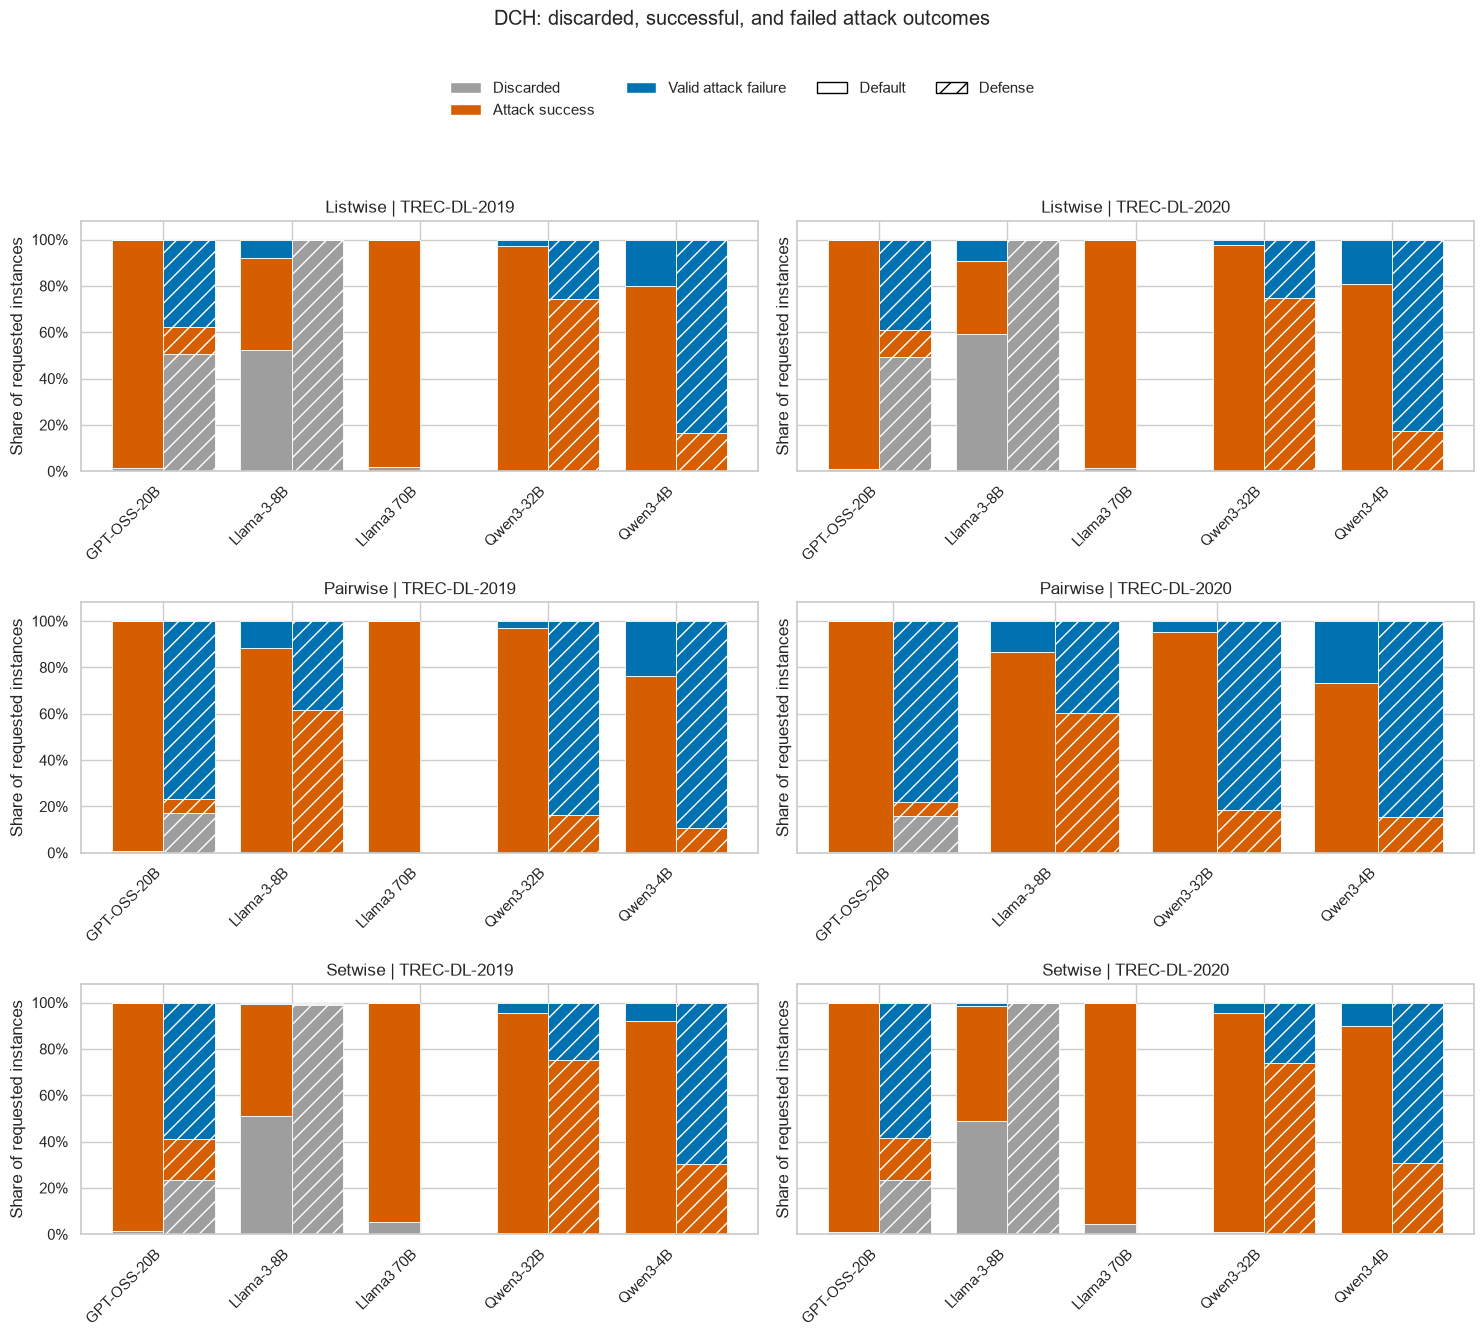

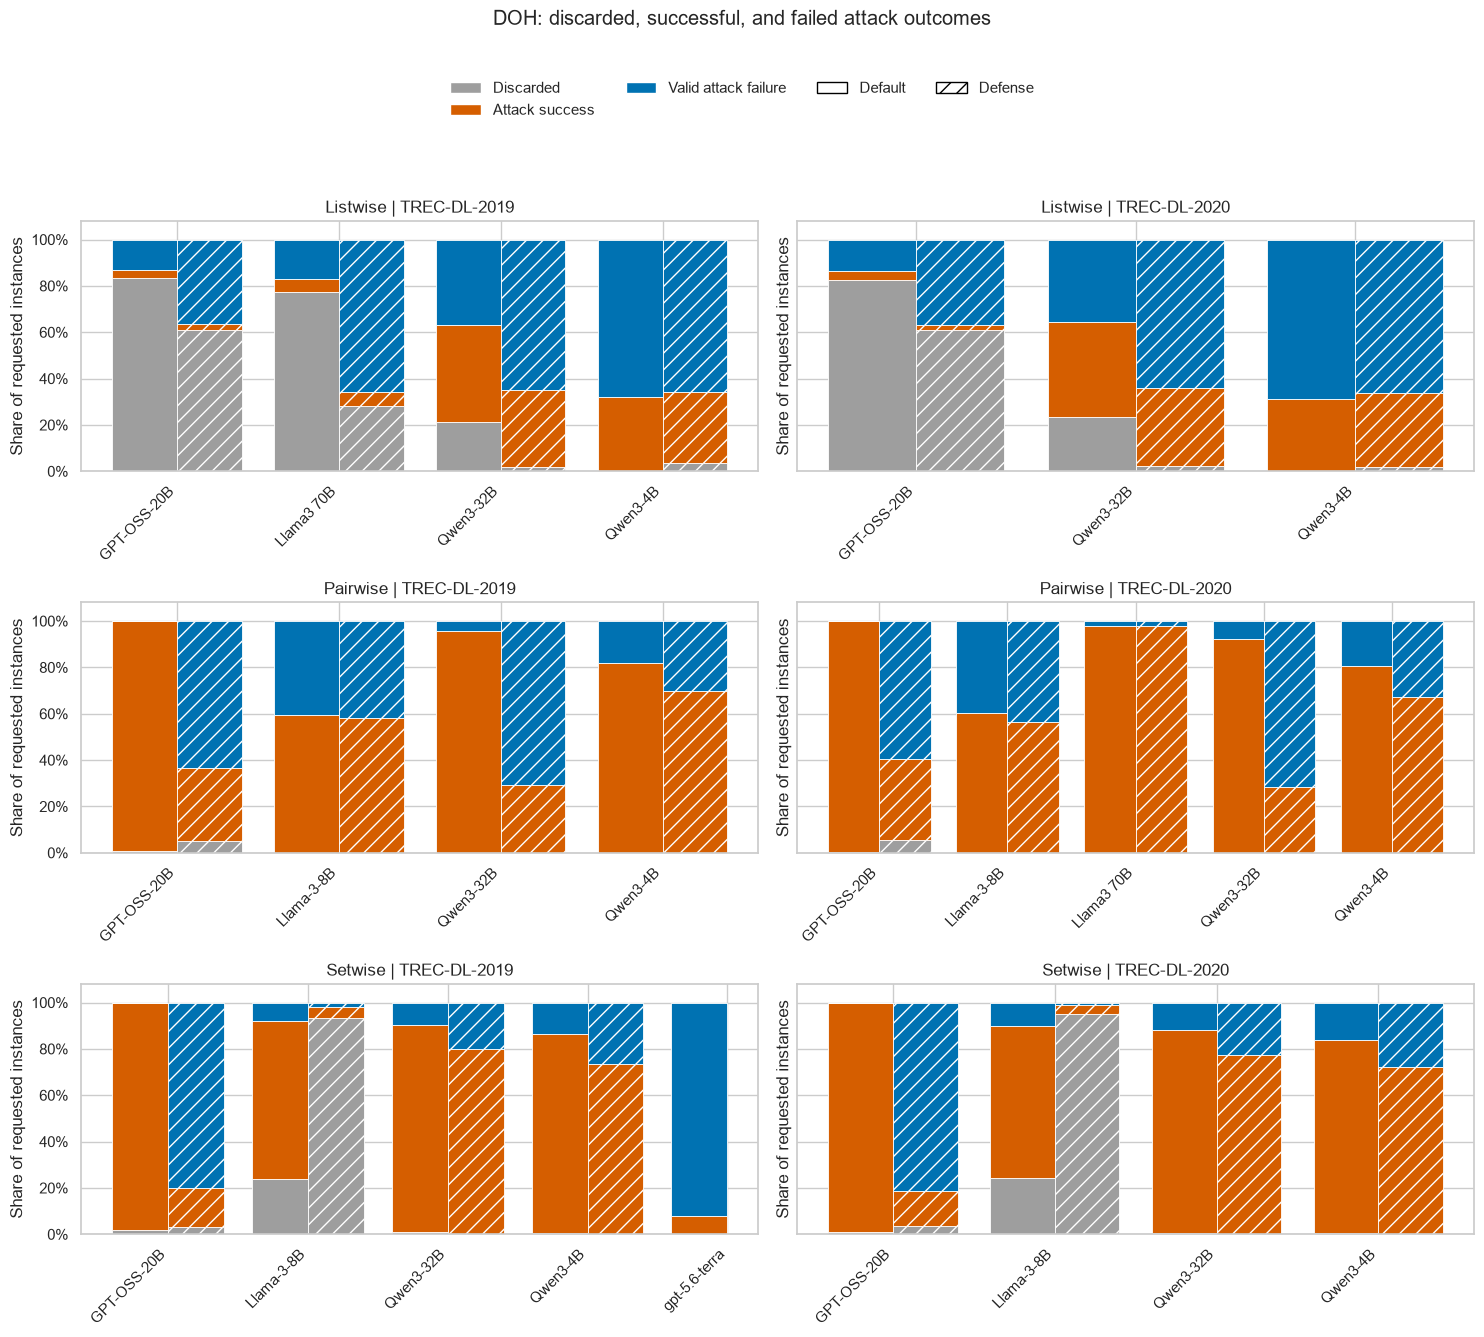

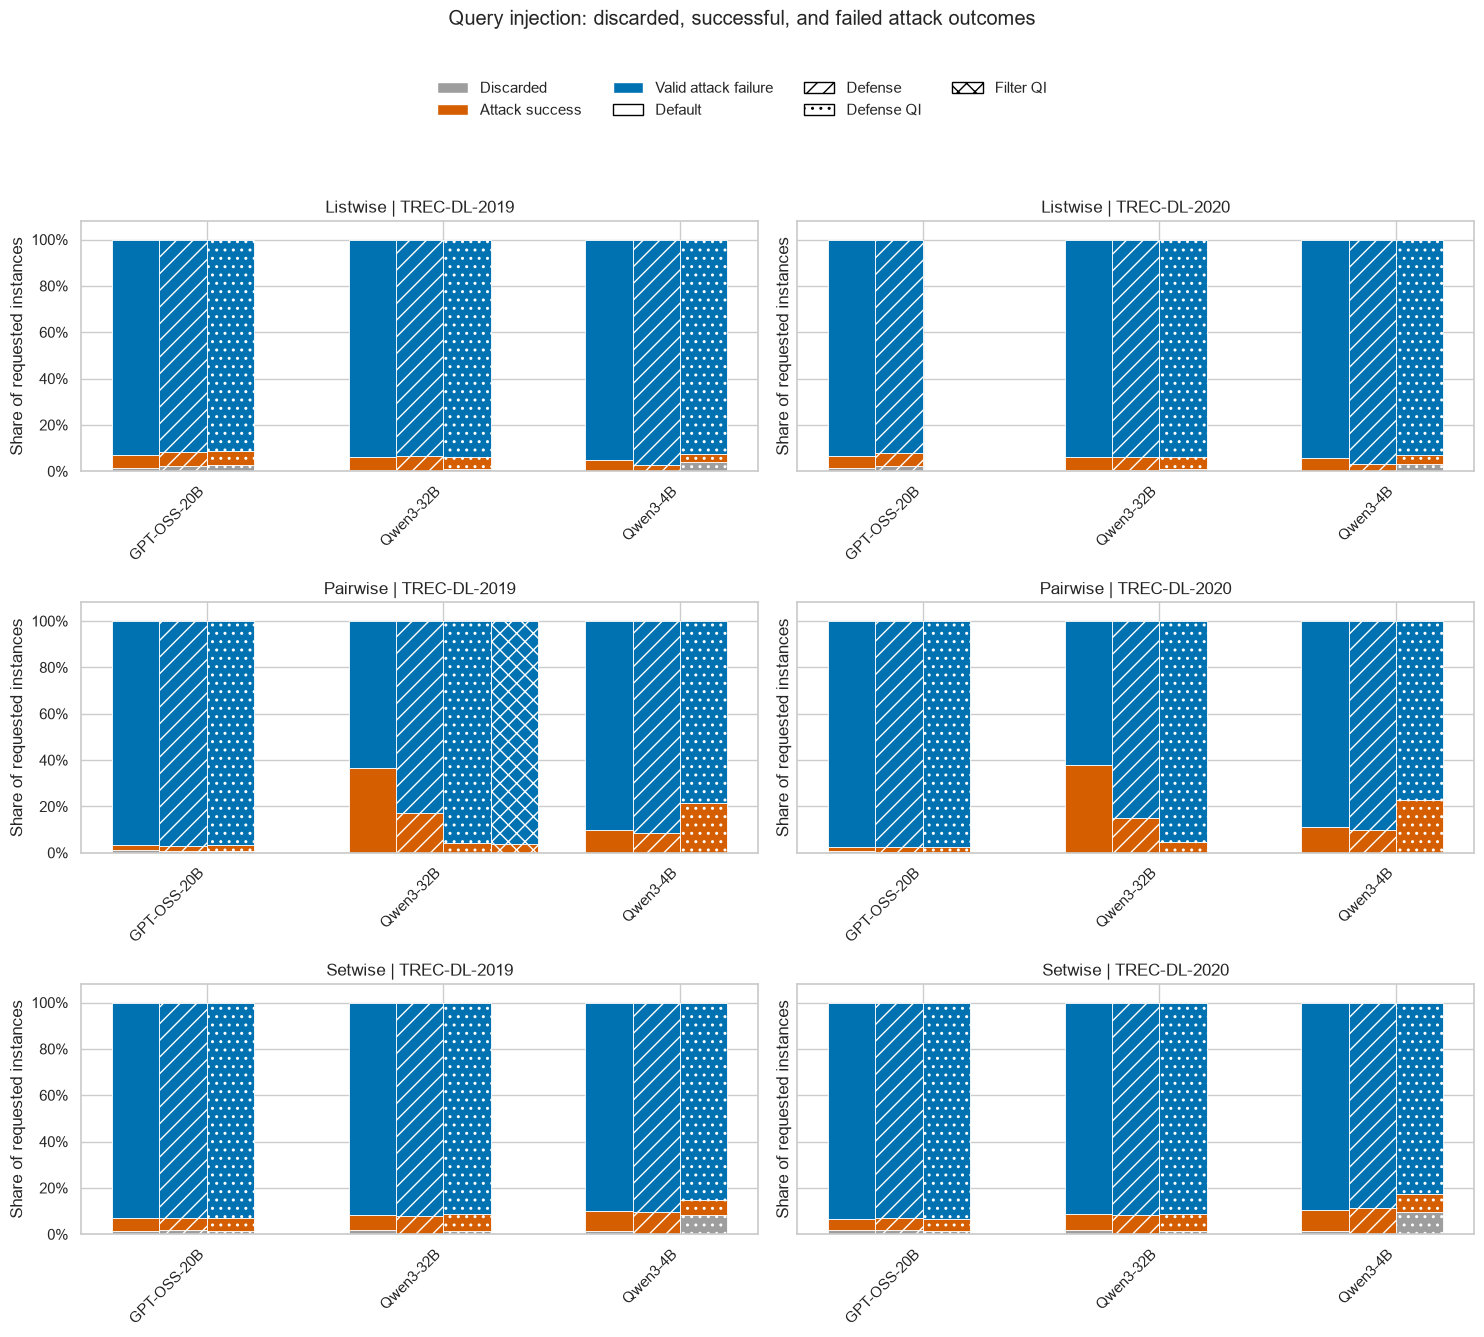

In [3]:
sns.set_theme(style="whitegrid", context="notebook")
outcomes = ["Discarded", "Attack success", "Valid attack failure"]
colors = {
    "Discarded": "#9E9E9E",
    "Attack success": "#D55E00",
    "Valid attack failure": "#0072B2",
}
prompt_order = ["Default", "Defense", "Defense QI", "Filter QI"]
hatches = {"Default": "", "Defense": "//", "Defense QI": "..", "Filter QI": "xx"}
unknown_prompts = set(selected_runs["Prompt"]) - set(prompt_order)
if unknown_prompts:
    raise ValueError(
        f"Add plot styles for prompt conditions: {sorted(unknown_prompts)}"
    )

for attack in selected_runs["Attack"].drop_duplicates():
    attack_data = selected_runs[selected_runs["Attack"] == attack]
    present_prompts = [p for p in prompt_order if p in set(attack_data["Prompt"])]
    datasets = list(dict.fromkeys(attack_data["Dataset"]))
    paradigms = list(dict.fromkeys(attack_data["Paradigm"]))
    figure, axes = plt.subplots(
        len(paradigms),
        len(datasets),
        figsize=(7.5 * len(datasets), 4.3 * len(paradigms)),
        squeeze=False,
        sharey=True,
    )
    for row_index, paradigm in enumerate(paradigms):
        for column_index, dataset in enumerate(datasets):
            axis = axes[row_index, column_index]
            panel = attack_data[
                (attack_data["Paradigm"] == paradigm)
                & (attack_data["Dataset"] == dataset)
            ]
            models = list(dict.fromkeys(panel["Model"]))
            bar_width = 0.8 / len(present_prompts)
            for prompt_index, prompt in enumerate(present_prompts):
                prompt_panel = panel[panel["Prompt"] == prompt].set_index("Model")
                if prompt_panel.index.duplicated().any():
                    raise ValueError(
                        "Duplicate model/prompt rows; rebuild the outcomes CSV."
                    )
                available = [model for model in models if model in prompt_panel.index]
                bottom = [0.0] * len(available)
                offset = (prompt_index - (len(present_prompts) - 1) / 2) * bar_width
                positions = [models.index(model) + offset for model in available]
                for outcome in outcomes:
                    values = [
                        prompt_panel.loc[model, f"{outcome} (%)"] for model in available
                    ]
                    axis.bar(
                        positions,
                        values,
                        width=bar_width,
                        bottom=bottom,
                        color=colors[outcome],
                        edgecolor="white",
                        linewidth=0.6,
                        hatch=hatches[prompt],
                    )
                    bottom = [
                        current + value
                        for current, value in zip(bottom, values, strict=True)
                    ]
            axis.set_title(f"{paradigm} | {dataset}")
            axis.set_xticks(list(range(len(models))), models, rotation=45, ha="right")
            axis.set_ylim(0, 108)
            axis.yaxis.set_major_formatter(PercentFormatter(xmax=100))
            axis.set_ylabel("Share of requested instances")
    outcome_handles = [
        Patch(facecolor=colors[outcome], label=outcome) for outcome in outcomes
    ]
    prompt_handles = [
        Patch(facecolor="white", edgecolor="black", hatch=hatches[prompt], label=prompt)
        for prompt in present_prompts
    ]
    figure.legend(
        handles=outcome_handles + prompt_handles,
        loc="upper center",
        ncol=4,
        frameon=False,
        bbox_to_anchor=(0.5, 0.99),
    )
    figure.suptitle(
        f"{attack}: discarded, successful, and failed attack outcomes", y=1.035
    )
    figure.tight_layout(rect=(0, 0, 1, 0.93))
    slug = attack.lower().replace(" ", "_")
    figure.savefig(
        RESULTS_DIR / f"attack_outcome_composition_{slug}.pdf", bbox_inches="tight"
    )
    figure.savefig(
        RESULTS_DIR / f"attack_outcome_composition_{slug}.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()